In [1]:
%run helper_file.ipynb
from qiskit import *
import math

The number of bitstrings is: 1024
The counts are: {'111': 546, '000': 478}


In [2]:
# Definition of the Flip Gate, if control = TRUE, the gate will be controlled by one qubit
def create_flip_gate(n:int, control:bool = False):
    A = QuantumRegister(n,"a")
    B = QuantumRegister(n - 1,"b")
    
    flip = QuantumCircuit(A,B, name= 'Flip')

    if n==2:
        flip.ccx(A[1],A[0],B[0])

    else:
        flip.ccx(A[n-1],B[n-3],B[n-2])

        for qubit in range(n - 2):
            flip.ccx(A[qubit+1],A[qubit], B[qubit])
        
        flip.ccx(A[n-1],B[n-3],B[n-2])
        
    if control:
      return flip.to_gate().control(1) # Build a controlled Flip gate if control = True
    else:
      return flip.to_gate()  # Otherwise build a Flip gate

In [3]:
# Definition of the andTemp Gate, if control = TRUE, the gate will be controlled by one qubit
def create_andTemp_gate(n:int, control:bool = False):
    tmpFlag = False
    A = QuantumRegister(n,"a")
    B = QuantumRegister(1, "b")
    C = QuantumRegister(n - 2,"c")
    
    andTemp = QuantumCircuit(A,B,C, name= 'andTemp')

    if A.size == 2:
        andTemp.ccx(A[1],A[0],B[0])

    else:

        FlipGate = create_flip_gate(n,tmpFlag)
        invFlipGate = create_flip_gate(n-1,tmpFlag) # used to reset register C

        D = C[:] + B[:] # create n-1 register with B[0] as highest-order qubit

        andTemp.append(FlipGate, A[:]+D[:])

        andTemp.append(invFlipGate, A[1:n]+C[:])
        
    if control:
      return andTemp.to_gate().control(1) # Build a controlled andTemp gate if control = True
    else:
      return andTemp.to_gate()  # Otherwise build an andTemp gate

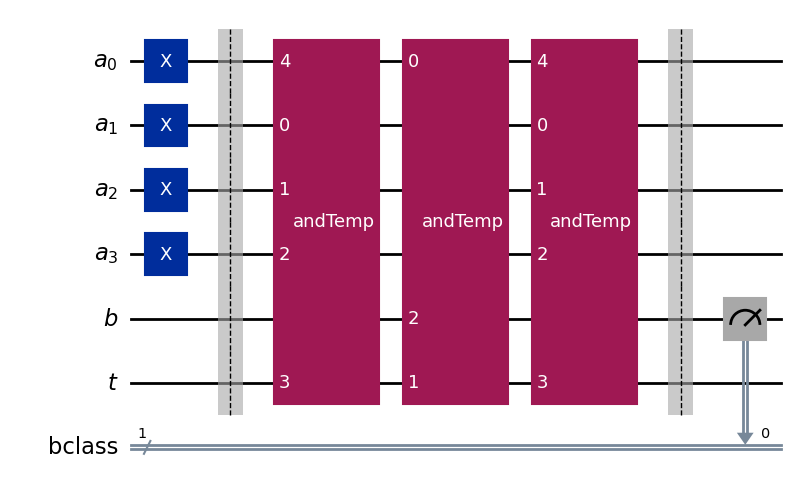

In [4]:
n = 4
control = False

A = QuantumRegister(n,"a")
B = QuantumRegister(1,"b")
T = QuantumRegister(1,"t")
B_C = ClassicalRegister(1,"bclass")

seed_a = '1111' 
seed_b = '0' 
seed_t = '0'
            # Expect B = |1>

andCirc = QuantumCircuit(A,B,T,B_C)

seed_a = list(map(int, list(seed_a)))[::-1] # Rearrange the initial values in reverse order according to Qiskit convention

# encode the value of register a
for bit in range(len(seed_a)):
    if seed_a[bit] == 1:
        andCirc.x(A[bit])
        
# Repeat the process for the initial value of register b
seed_b = list(map(int, list(seed_b)))[::-1] 

# encode the value of register b
for bit in range(len(seed_b)):
    if seed_b[bit] == 1:
        andCirc.x(B[bit])

# Repeat the process for the initial value of register c
seed_t = list(map(int, list(seed_t)))[::-1] 

# encode the value of register c
for bit in range(len(seed_t)):
    if seed_t[bit] == 1:
        andCirc.x(T[bit])

andCirc.barrier()

if n == 1:
    andCirc.cx(A[0],B[0])

elif n== 2:
    andCirc.ccx(A[1],A[0],B[0])

else:

    if n%2 == 1:
        k = math.floor(n/2)
        j = k-1
        AndTempGate = create_andTemp_gate(k+1,control)
        D = A[0:j+1] + T[:] # create lower register with T[0] as highest-order qubit
        

        andCirc.append(AndTempGate, A[k:n]+T[:]+A[0:j])
        andCirc.append(AndTempGate, D[:]+B[:]+A[k:k+j])
        andCirc.append(AndTempGate, A[k:n]+T[:]+A[0:j])


    else:
        k = math.floor(n/2) - 1
        j = k-1
        AndTempGate1 = create_andTemp_gate(k+2,control)
        AndTempGate2 = create_andTemp_gate(k+1,control)
        D = A[0:j+1] + T[:] # create lower register with T[0] as highest-order qubit
        

        andCirc.append(AndTempGate1, A[k:n]+T[:]+A[0:j+1])
        andCirc.append(AndTempGate2, D[:]+B[:]+A[k:k+j])
        andCirc.append(AndTempGate1, A[k:n]+T[:]+A[0:j+1])




andCirc.barrier()

andCirc.measure(B,B_C)

andCirc.draw(output='mpl')

In [5]:
from qiskit_aer.primitives import SamplerV2
 
sampler = SamplerV2()
job_simulator = sampler.run([andCirc.decompose(reps=6)], shots = 1024)

result_simulator = job_simulator.result()
counts1 = result_simulator[0].data.bclass.get_counts() #data."measure label"

print(counts1)

{'1': 1024}


In [6]:
from qiskit_aer import AerProvider, AerSimulator, QasmSimulator, StatevectorSimulator, UnitarySimulator
from qiskit.visualization import *
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Estimator, Session, Options

#Load your IBM Quantum account(s)
service = QiskitRuntimeService(channel = "ibm_cloud")

backend = service.least_busy(simulator = False, operational = True)
print(backend)

<IBMBackend('ibm_fez')>


In [7]:
# Import the NoiseModel
from qiskit_aer.noise import NoiseModel

# Create the noise model based on the backend properties
noise_model = NoiseModel.from_backend(backend)
# Get coupling map from backend
coupling_map = backend.configuration().coupling_map
# Get basis gates from noise model
basis_gates = noise_model.basis_gates
# Get the Aer simulator to apply noise model
noisy_simulator = AerSimulator()

opt_level = 3
pass_manager = generate_preset_pass_manager(backend = noisy_simulator, optimization_level = opt_level)
isa_circuit = pass_manager.run(andCirc)

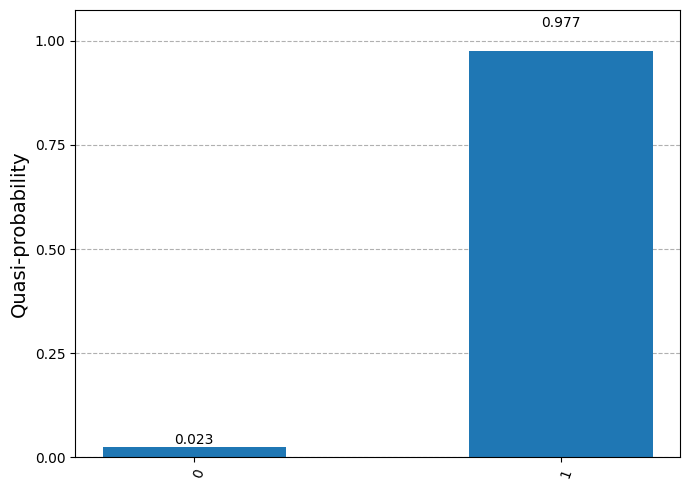

In [8]:
# Execute the circuit on the simulator with the backend properties, and generated noise model
result = noisy_simulator.run(isa_circuit, coupling_map = coupling_map, basis_gates = basis_gates, noise_model = noise_model).result()
# Obtain and print results
counts = result.get_counts()
plot_distribution(counts)

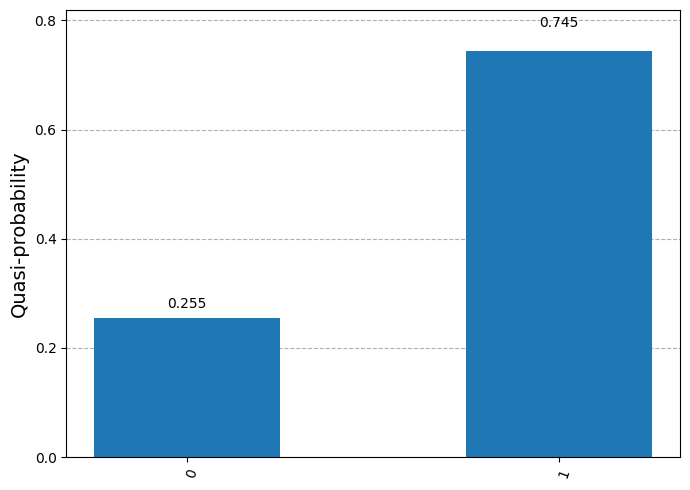

In [9]:
# Execute circuit on backend
pass_manager = generate_preset_pass_manager(backend = backend)
isa_circuit = pass_manager.run(andCirc)

sampler = Sampler(mode = backend)

result = sampler.run([isa_circuit]).result()

# Get results for the first (and only) PUB
pub_result = result[0]
counts = pub_result.data.bclass.get_counts()
plot_distribution(counts)

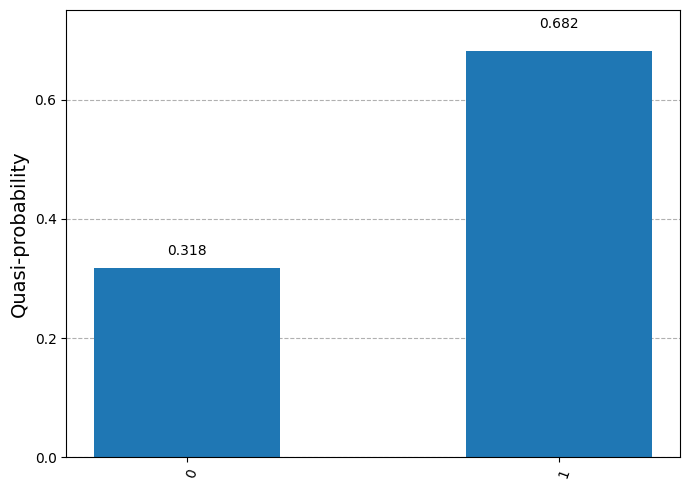

In [10]:
# Execute circuit on backend with optimization level

pass_manager = generate_preset_pass_manager(backend = backend, optimization_level = opt_level)
isa_circuit = pass_manager.run(andCirc)

sampler = Sampler(mode = backend)

result = sampler.run([isa_circuit]).result()

# Get results for the first (and only) PUB
pub_result = result[0]
counts = pub_result.data.bclass.get_counts()
plot_distribution(counts)